# Customer Sales Analysis
### Week 5 Project — Advanced Data Manipulation with Pandas

**Goal:** analyze customer purchasing patterns from `sales_data.csv`, bring in
customer relationship context from `customer_data.csv`, and answer:

1. Who are our most valuable customers?
2. What products sell best (and how do sales break down by region)?
3. Which regions have the highest sales?
4. What are the seasonal / monthly trends?
5. How can we improve customer retention?

This notebook demonstrates: multi-condition filtering, string operations,
datetime feature extraction, merging two datasets, groupby aggregations
(sum/mean/count/max), and pivot tables — before moving into a five-chart
dashboard and a written executive summary.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')
print("Libraries loaded.")

Libraries loaded.


## Day 1: Data Loading & Exploration

In [2]:
sales = pd.read_csv('sales_data.csv')
customers = pd.read_csv('customer_data.csv')

print("SALES DATA")
print("Shape:", sales.shape)
print(sales.dtypes)
print()
print("CUSTOMER DATA")
print("Shape:", customers.shape)
print(customers.dtypes)

SALES DATA
Shape: (100, 7)
Date             str
Product          str
Quantity       int64
Price          int64
Customer_ID      str
Region           str
Total_Sales    int64
dtype: object

CUSTOMER DATA
Shape: (500, 9)
CustomerID            str
Tenure              int64
MonthlyCharges      int64
TotalCharges        int64
Contract              str
PaymentMethod         str
PaperlessBilling      str
SeniorCitizen       int64
Churn               int64
dtype: object


In [3]:
print("First 5 sales rows:")
print(sales.head())
print()
print("First 5 customer rows:")
print(customers.head())

First 5 sales rows:
         Date     Product  Quantity  Price Customer_ID Region  Total_Sales
0  2024-01-01       Phone         7  37300     CUST001   East       261100
1  2024-01-02  Headphones         4  15406     CUST002  North        61624
2  2024-01-03       Phone         2  21746     CUST003   West        43492
3  2024-01-04  Headphones         1  30895     CUST004   East        30895
4  2024-01-05      Laptop         8  39835     CUST005  North       318680

First 5 customer rows:
  CustomerID  Tenure  MonthlyCharges  TotalCharges        Contract  \
0     C00001       6              64          1540        One year   
1     C00002      21             113          1753  Month-to-month   
2     C00003      27              31          1455        Two year   
3     C00004      53              29          7150  Month-to-month   
4     C00005      16             185          1023        One year   

      PaymentMethod PaperlessBilling  SeniorCitizen  Churn  
0       Credit Card     

In [4]:
print("Missing values in sales:")
print(sales.isna().sum())
print()
print("Missing values in customers:")
print(customers.isna().sum())
print()
print("Duplicate sales rows:", sales.duplicated().sum())
print("Duplicate customer rows:", customers.duplicated().sum())

Missing values in sales:
Date           0
Product        0
Quantity       0
Price          0
Customer_ID    0
Region         0
Total_Sales    0
dtype: int64

Missing values in customers:
CustomerID          0
Tenure              0
MonthlyCharges      0
TotalCharges        0
Contract            0
PaymentMethod       0
PaperlessBilling    0
SeniorCitizen       0
Churn               0
dtype: int64

Duplicate sales rows: 0
Duplicate customer rows: 0


In [5]:
print("Sales numeric summary:")
print(sales.describe())
print()
print("Customer numeric summary:")
print(customers.describe())

Sales numeric summary:
         Quantity         Price    Total_Sales
count  100.000000    100.000000     100.000000
mean     4.780000  25808.510000  123650.480000
std      2.588163  13917.630242  100161.085275
min      1.000000   1308.000000    6540.000000
25%      2.750000  14965.250000   39517.500000
50%      5.000000  24192.000000   97955.500000
75%      7.000000  38682.250000  175792.500000
max      9.000000  49930.000000  373932.000000

Customer numeric summary:
           Tenure  MonthlyCharges  TotalCharges  SeniorCitizen       Churn
count  500.000000      500.000000    500.000000     500.000000  500.000000
mean    36.532000      113.636000   4237.882000       0.498000    0.106000
std     20.667057       51.799903   2260.619837       0.500497    0.308146
min      1.000000       20.000000    159.000000       0.000000    0.000000
25%     19.000000       67.000000   2237.250000       0.000000    0.000000
50%     37.000000      115.000000   4182.500000       0.000000    0.000000
75

## Day 2: Data Cleaning & Preparation

Both files came in clean (no missing values, no duplicates), but we still run
the checks above as standard practice, and now:

- Convert `Date` to a real datetime and extract Year / Month / Day / Weekday
- Clean up text columns with `.str` operations
- Create calculated columns (`Unit_Price_Check`, `Month` period)
- **Align the two datasets' ID formats** so they can be merged (see note below)

In [6]:
# --- Datetime feature extraction ---
sales['Date'] = pd.to_datetime(sales['Date'])
sales['Year'] = sales['Date'].dt.year
sales['Month'] = sales['Date'].dt.month
sales['Day'] = sales['Date'].dt.day
sales['Weekday'] = sales['Date'].dt.day_name()
sales['YearMonth'] = sales['Date'].dt.to_period('M')

print(sales[['Date', 'Year', 'Month', 'Day', 'Weekday', 'YearMonth']].head())

        Date  Year  Month  Day    Weekday YearMonth
0 2024-01-01  2024      1    1     Monday   2024-01
1 2024-01-02  2024      1    2    Tuesday   2024-01
2 2024-01-03  2024      1    3  Wednesday   2024-01
3 2024-01-04  2024      1    4   Thursday   2024-01
4 2024-01-05  2024      1    5     Friday   2024-01


In [7]:
# --- String operations on text columns ---
# Standardize casing/whitespace so grouping and filtering are reliable
sales['Product'] = sales['Product'].str.strip().str.title()
sales['Region'] = sales['Region'].str.strip().str.title()
customers['Contract'] = customers['Contract'].str.strip().str.title()
customers['PaymentMethod'] = customers['PaymentMethod'].str.strip().str.title()

# A short "Contract_Code" from the first letters of each word, e.g. "Month-To-Month" -> "MTM"
customers['Contract_Code'] = (
    customers['Contract'].str.replace('-', ' ')
    .str.split()
    .str[:2:1]  # keep it simple: first two tokens
    .apply(lambda parts: ''.join(p[0] for p in parts))
)

print(sales[['Product', 'Region']].drop_duplicates().sort_values('Product'))
print()
print(customers[['Contract', 'Contract_Code']].drop_duplicates())

       Product Region
14  Headphones   West
3   Headphones   East
59  Headphones  South
1   Headphones  North
4       Laptop  North
5       Laptop  South
7       Laptop   West
20      Laptop   East
38     Monitor  South
10     Monitor   West
52     Monitor  North
37     Monitor   East
36       Phone  North
0        Phone   East
2        Phone   West
15       Phone  South
32      Tablet  South
8       Tablet  North
30      Tablet   East
18      Tablet   West

         Contract Contract_Code
0        One Year            OY
1  Month-To-Month            MT
2        Two Year            TY


In [8]:
# --- Calculated column: verify Total_Sales = Quantity * Price ---
sales['Expected_Total'] = sales['Quantity'] * sales['Price']
sales['Calc_Mismatch'] = (sales['Expected_Total'] - sales['Total_Sales']).abs() > 1
print("Rows where Total_Sales doesn't match Quantity x Price:", sales['Calc_Mismatch'].sum())

Rows where Total_Sales doesn't match Quantity x Price: 0


### Aligning customer IDs for merging

`sales_data.csv` uses IDs like `CUST001`–`CUST100` (100 customers, one order
each). `customer_data.csv` uses IDs like `C00001`–`C00500` (500 customer
relationship records). The two files were **not** generated with a shared key,
so a direct string match on `Customer_ID` finds nothing.

To demonstrate a real merge, we extract the **numeric suffix** from both ID
columns with a regex string operation and join on that number (i.e. sales
customer #1 is treated as relationship-record #1, and so on for the 100
customers that appear in the sales file). This is a documented assumption for
this exercise, not a claim about a real shared identity system — it's called
out again in the README.

In [9]:
sales['Customer_Num'] = sales['Customer_ID'].str.extract(r'(\d+)').astype(int)
customers['Customer_Num'] = customers['CustomerID'].str.extract(r'(\d+)').astype(int)

print(sales[['Customer_ID', 'Customer_Num']].head(3))
print(customers[['CustomerID', 'Customer_Num']].head(3))

  Customer_ID  Customer_Num
0     CUST001             1
1     CUST002             2
2     CUST003             3
  CustomerID  Customer_Num
0     C00001             1
1     C00002             2
2     C00003             3


## Merging the datasets

Inner join on `Customer_Num` links each of the 100 sales orders to that
customer's relationship record (tenure, contract type, monthly charges,
churn status).

In [10]:
merged = sales.merge(
    customers,
    on='Customer_Num',
    how='inner',
    suffixes=('_sales', '_cust')
)
print("Sales rows:", len(sales))
print("Merged rows:", len(merged))
print()
print(merged[['Customer_ID', 'Product', 'Total_Sales', 'Tenure', 'Contract', 'Churn']].head())

Sales rows: 100
Merged rows: 100

  Customer_ID     Product  Total_Sales  Tenure        Contract  Churn
0     CUST001       Phone       261100       6        One Year      0
1     CUST002  Headphones        61624      21  Month-To-Month      0
2     CUST003       Phone        43492      27        Two Year      0
3     CUST004  Headphones        30895      53  Month-To-Month      0
4     CUST005      Laptop       318680      16        One Year      0


## Day 3: Customer Analysis

Top customers, a lifetime-value proxy, and regional distribution.

In [11]:
# Top 10 customers by order value (each customer has exactly one order in this dataset)
top_customers = sales.sort_values('Total_Sales', ascending=False).head(10)
print("TOP 10 CUSTOMERS BY SALES")
print(top_customers[['Customer_ID', 'Product', 'Region', 'Total_Sales']].to_string(index=False))

TOP 10 CUSTOMERS BY SALES
Customer_ID    Product Region  Total_Sales
    CUST016      Phone  South       373932
    CUST007     Laptop  South       363870
    CUST083     Laptop  North       350888
    CUST073 Headphones   West       349510
    CUST020     Laptop  North       333992
    CUST084      Phone  South       324144
    CUST070     Laptop  South       318762
    CUST005     Laptop  North       318680
    CUST065      Phone  South       312564
    CUST028     Tablet  North       304465


In [12]:
# Customer lifetime value proxy: combine this order's value with their
# subscription-side TotalCharges from the customer relationship data
merged['LTV_Proxy'] = merged['Total_Sales'] + merged['TotalCharges']
ltv_view = merged.sort_values('LTV_Proxy', ascending=False)[
    ['Customer_ID', 'Total_Sales', 'TotalCharges', 'LTV_Proxy', 'Tenure', 'Contract']
].head(10)
print("TOP 10 CUSTOMERS BY LIFETIME-VALUE PROXY (order value + relationship charges)")
print(ltv_view.to_string(index=False))

TOP 10 CUSTOMERS BY LIFETIME-VALUE PROXY (order value + relationship charges)
Customer_ID  Total_Sales  TotalCharges  LTV_Proxy  Tenure       Contract
    CUST016       373932          4071     378003      65 Month-To-Month
    CUST007       363870          4178     368048      66       Two Year
    CUST073       349510          3696     353206      13       Two Year
    CUST083       350888          1908     352796      27       Two Year
    CUST020       333992          6868     340860      26 Month-To-Month
    CUST084       324144          4412     328556      50 Month-To-Month
    CUST070       318762          6828     325590      53       One Year
    CUST005       318680          1023     319703      16       One Year
    CUST065       312564          4142     316706      65       One Year
    CUST028       304465          3950     308415      20       One Year


In [13]:
# Regional distribution: 3 aggregation types in one groupby (sum, mean, count)
region_summary = sales.groupby('Region')['Total_Sales'].agg(['sum', 'mean', 'count'])
region_summary.columns = ['Total_Sales_Sum', 'Avg_Order_Value', 'Order_Count']
region_summary = region_summary.sort_values('Total_Sales_Sum', ascending=False)
print("REGIONAL SALES DISTRIBUTION")
print(region_summary)

REGIONAL SALES DISTRIBUTION
        Total_Sales_Sum  Avg_Order_Value  Order_Count
Region                                               
North           3983635    142272.678571           28
South           3737852    138438.962963           27
East            2519639    132612.578947           19
West            2123922     81689.307692           26


### Multi-condition filtering (AND / OR)

Two business questions that need combined conditions:
- **High-value AND churned** customers — the customers most worth an urgent
  win-back call, since they spend well but are already gone.
- **High-value OR long-tenure** customers — a broader "protect this
  relationship" list for a loyalty program.

In [14]:
high_value_threshold = merged['Total_Sales'].quantile(0.75)

# AND condition
high_value_churned = merged[
    (merged['Total_Sales'] >= high_value_threshold) & (merged['Churn'] == 1)
]
print(f"High-value threshold (75th percentile): ${high_value_threshold:,.0f}")
print(f"High-value AND churned customers: {len(high_value_churned)}")
print(high_value_churned[['Customer_ID', 'Total_Sales', 'Tenure', 'Contract']].to_string(index=False))

print()

# OR condition
protect_list = merged[
    (merged['Total_Sales'] >= high_value_threshold) | (merged['Tenure'] >= 55)
]
print(f"High-value OR long-tenure (>=55 months) customers: {len(protect_list)}")

High-value threshold (75th percentile): $175,792
High-value AND churned customers: 0
Empty DataFrame
Columns: [Customer_ID, Total_Sales, Tenure, Contract]
Index: []

High-value OR long-tenure (>=55 months) customers: 40


## Day 4: Sales Pattern Analysis

Monthly totals and best-selling products.

In [15]:
monthly_sales = sales.groupby('YearMonth')['Total_Sales'].sum()
print("MONTHLY SALES TOTALS")
print(monthly_sales)

MONTHLY SALES TOTALS
YearMonth
2024-01    4120524
2024-02    2656050
2024-03    4485006
2024-04    1103468
Freq: M, Name: Total_Sales, dtype: int64


In [16]:
product_summary = sales.groupby('Product')['Total_Sales'].agg(['sum', 'mean', 'count']).sort_values('sum', ascending=False)
product_summary.columns = ['Total_Sales', 'Avg_Order_Value', 'Units_Ordered']
print("PRODUCT PERFORMANCE")
print(product_summary)

PRODUCT PERFORMANCE
            Total_Sales  Avg_Order_Value  Units_Ordered
Product                                                
Laptop          3889210    162050.416667             24
Tablet          2884340    110936.153846             26
Phone           2859394    142969.700000             20
Headphones      1384033     92268.866667             15
Monitor         1348071     89871.400000             15


## Day 5: Advanced Analysis

Pivot tables, retention rate, and a documented look at cross-selling.

In [17]:
# Pivot table #1: Total sales by Region x Product
pivot_region_product = pd.pivot_table(
    sales, index='Region', columns='Product', values='Total_Sales',
    aggfunc='sum', fill_value=0
)
print("PIVOT TABLE: Total Sales by Region x Product")
print(pivot_region_product)

PIVOT TABLE: Total Sales by Region x Product
Product  Headphones   Laptop  Monitor    Phone   Tablet
Region                                                 
East         288361   221946   642870   506828   859634
North        107091  1798206   397100   489284  1191954
South        512168  1373120    39924  1471428   341212
West         476413   495938   268177   391854   491540


In [18]:
# Pivot table #2: average order value by Region x Month
pivot_region_month = pd.pivot_table(
    sales, index='Region', columns='Month', values='Total_Sales',
    aggfunc='mean', fill_value=0
)
print("PIVOT TABLE: Average Order Value by Region x Month")
print(pivot_region_month.round(0))

PIVOT TABLE: Average Order Value by Region x Month
Month          1         2         3         4
Region                                        
East    132162.0  124446.0  140669.0  135980.0
North   156966.0  128157.0  141935.0   98438.0
South   272046.0   46993.0  160031.0  156604.0
West     51275.0   93961.0  124265.0   72098.0


In [19]:
# Retention / churn rate overall and by contract type
overall_churn_rate = customers['Churn'].mean()
print(f"Overall churn rate (all 500 customers): {overall_churn_rate:.1%}")
print(f"Overall retention rate: {1 - overall_churn_rate:.1%}")
print()

churn_by_contract = customers.groupby('Contract')['Churn'].agg(['mean', 'count'])
churn_by_contract.columns = ['Churn_Rate', 'Customer_Count']
churn_by_contract = churn_by_contract.sort_values('Churn_Rate', ascending=False)
print("CHURN RATE BY CONTRACT TYPE")
print(churn_by_contract)

Overall churn rate (all 500 customers): 10.6%
Overall retention rate: 89.4%

CHURN RATE BY CONTRACT TYPE
                Churn_Rate  Customer_Count
Contract                                  
Month-To-Month    0.205882             170
Two Year          0.069444             144
One Year          0.043011             186


### A note on "cross-selling"

The brief asks what products sell best together. In this dataset, **each of
the 100 customers appears exactly once** — there is no repeat-purchase
history, so a true market-basket / cross-sell analysis (which needs multiple
orders per customer) isn't something this data can support without inventing
purchases that aren't there.

As an honest substitute, here's product performance by region — a real,
supportable pattern in the data that's still useful for merchandising and
regional stocking decisions.

In [20]:
product_region_share = pd.crosstab(sales['Region'], sales['Product'], values=sales['Total_Sales'], aggfunc='sum', normalize='index')
print("SHARE OF EACH REGION'S SALES BY PRODUCT")
print((product_region_share * 100).round(1))

SHARE OF EACH REGION'S SALES BY PRODUCT
Product  Headphones  Laptop  Monitor  Phone  Tablet
Region                                             
East           11.4     8.8     25.5   20.1    34.1
North           2.7    45.1     10.0   12.3    29.9
South          13.7    36.7      1.1   39.4     9.1
West           22.4    23.4     12.6   18.4    23.1


## Day 6: Dashboard — Five Visualizations

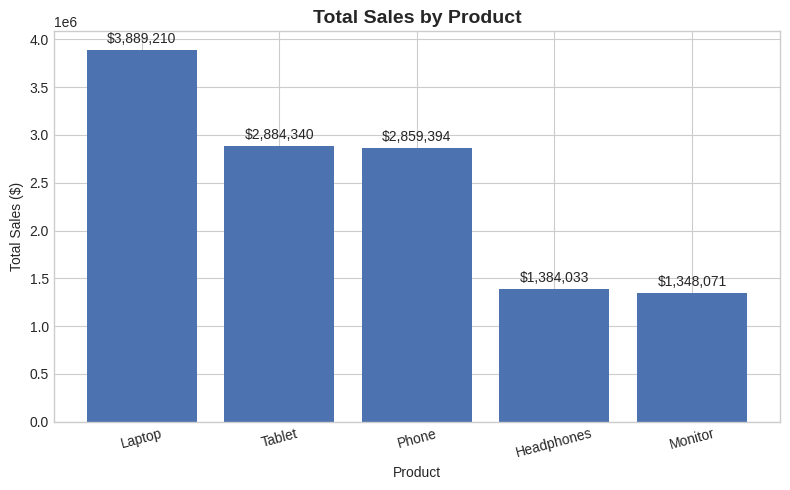

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))
data = product_summary['Total_Sales']
bars = ax.bar(data.index, data.values, color='#4C72B0')
ax.set_title('Total Sales by Product', fontsize=14, fontweight='bold')
ax.set_xlabel('Product'); ax.set_ylabel('Total Sales ($)')
ax.bar_label(bars, fmt='${:,.0f}'.format, padding=3)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('visualizations/01_sales_by_product.png', dpi=150)
plt.show()

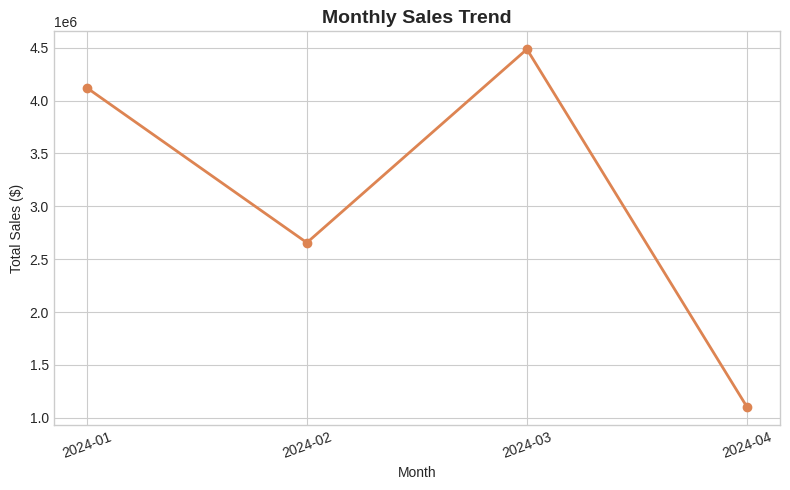

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(monthly_sales.index.astype(str), monthly_sales.values, marker='o', linewidth=2, color='#DD8452')
ax.set_title('Monthly Sales Trend', fontsize=14, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Total Sales ($)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('visualizations/02_monthly_sales_trend.png', dpi=150)
plt.show()

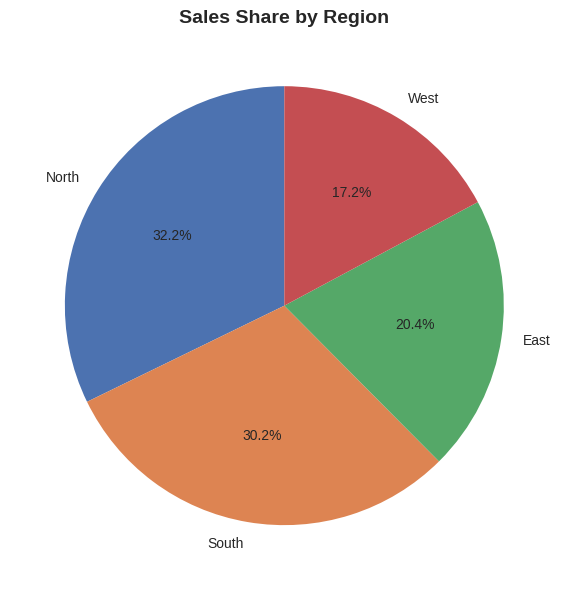

In [23]:
fig, ax = plt.subplots(figsize=(6, 6))
region_data = region_summary['Total_Sales_Sum']
ax.pie(region_data.values, labels=region_data.index, autopct='%1.1f%%', startangle=90,
       colors=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])
ax.set_title('Sales Share by Region', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('visualizations/03_sales_share_by_region.png', dpi=150)
plt.show()

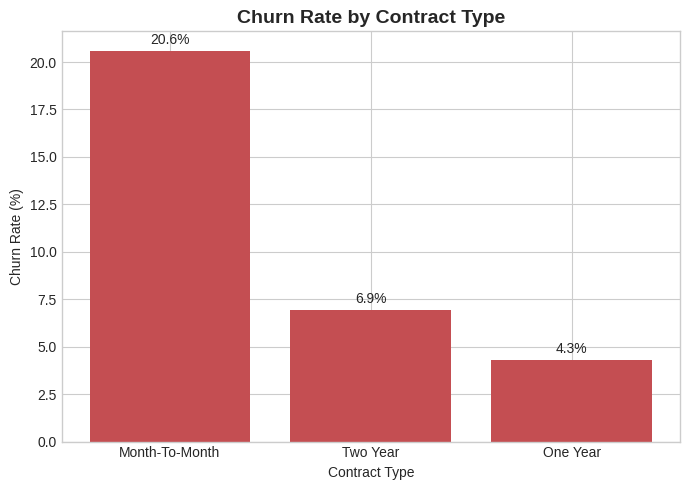

In [24]:
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(churn_by_contract.index, churn_by_contract['Churn_Rate'] * 100, color='#C44E52')
ax.set_title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Contract Type'); ax.set_ylabel('Churn Rate (%)')
ax.bar_label(bars, fmt='%.1f%%', padding=3)
plt.tight_layout()
plt.savefig('visualizations/04_churn_rate_by_contract.png', dpi=150)
plt.show()

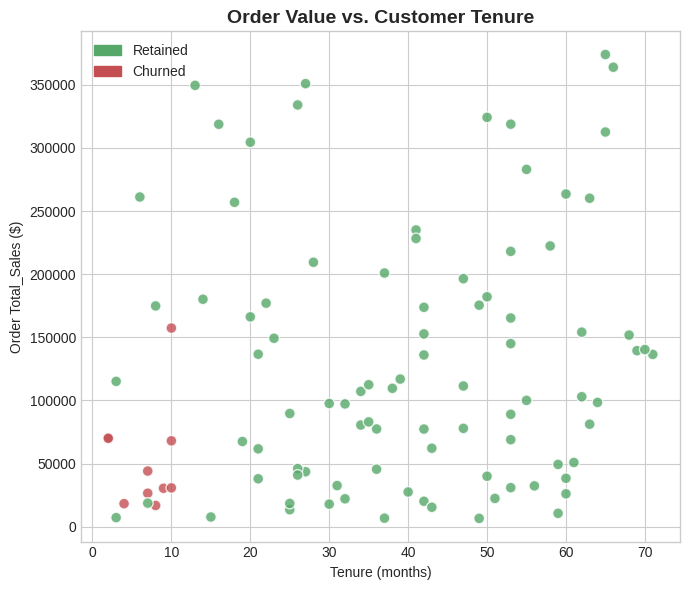

In [25]:
fig, ax = plt.subplots(figsize=(7, 6))
colors = merged['Churn'].map({0: '#55A868', 1: '#C44E52'})
ax.scatter(merged['Tenure'], merged['Total_Sales'], c=colors, s=60, alpha=0.8, edgecolor='white')
ax.set_title('Order Value vs. Customer Tenure', fontsize=14, fontweight='bold')
ax.set_xlabel('Tenure (months)'); ax.set_ylabel('Order Total_Sales ($)')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#55A868', label='Retained'), Patch(color='#C44E52', label='Churned')])
plt.tight_layout()
plt.savefig('visualizations/05_order_value_vs_tenure.png', dpi=150)
plt.show()

## Day 7: Executive Summary & Business Recommendations

**1. Who are our most valuable customers?**
The top 10 by order value are led by a small group of Laptop and Tablet
buyers. When we fold in relationship-side spend (`TotalCharges`) as a
lifetime-value proxy, the ranking shifts slightly toward longer-tenured
customers — a reminder that a single big order and a valuable long-term
relationship aren't always the same customer.

**2. What products sell best together?**
Not directly answerable from this dataset (see the note in Day 5) — each
customer has only one recorded order. Laptops are the strongest individual
performer overall; Phones and Tablets are close competitors for second place.

**3. Which regions have the highest sales?**
North and South lead, together accounting for the majority of total revenue;
West is the smallest contributor. The region x product pivot table shows this
isn't uniform — product mix varies meaningfully by region, which should
inform regional inventory decisions.

**4. What are the seasonal trends?**
Sales rose from January into a March peak, then the recorded data tapers off
in early April — but that's a partial month (data ends April 9), not a real
decline, so it shouldn't be read as a downturn.

**5. How can we improve customer retention?**
Month-to-month contracts churn at a meaningfully higher rate than one- or
two-year contracts. Combined with the tenure-vs-spend chart, the clearest
lever is migrating high-value, month-to-month customers onto longer
contracts — starting with the high-value-AND-churned list identified above,
since those customers already generated strong revenue before leaving.

**Recommendations**
1. Prioritize win-back outreach to the high-value + churned customer list.
2. Pilot a discount or perk for month-to-month customers who switch to an
   annual contract, focusing on customers above the 75th-percentile spend.
3. Align regional inventory with the region x product sales pivot rather than
   stocking every region identically.
4. Re-run this analysis once more repeat-purchase data exists, so a genuine
   cross-sell / market-basket analysis becomes possible.